In [ ]:
from copy import deepcopy as copy

import numpy as np
import jax
import jax.numpy as jnp
import diffrax
import jax.random as jr

In [ ]:
from aux import gaussian_if_under_val

In [4]:
SEED = 8015
BATCH_SIZE = 5
N_INNER_LOOP_RANGE = (
    320,
    321,
)  # Number of times to simulate network and plasticity rules per loss function evaluation
decoder_train_trial_nums = (280, 300)
decoder_test_trial_nums = (300, 320)
READOUTS_PER_TRIAL = 20
STD_EXPL = 0.001
DW_LAG = 5
FIXED_DATA = True
L1_PENALTIES = [5e-7]
CALC_TEST_SET_LOSS_FREQ = 11
ACTIVITY_LOSS_COEF = 50.0
CHANGE_PROB_PER_ITER = 0.0
FRAC_INPUTS_FIXED = 0.0
INPUT_RATE_PER_CELL = 1000
INPUT_BLOCK_DURATION = 5e-3
N_RULES = 60 + 16
N_TIMECONSTS = 36 + 32

hd_hd_sparsity = 1.0
hd_hr_sparsity = 1.0
struct_prior = "shift"

T = 0.100  # Total duration of one network simulation
dt = 1e-4  # Timestep
input_start = int(20e-3 / dt)
input_end = int(100e-3 / dt)
input_len = input_end - input_start
input_block_timesteps = int(INPUT_BLOCK_DURATION / dt)
time = np.linspace(0, T, int(T / dt))
n_e_pool = 40  # Number excitatory cells in sequence (also length of sequence)
n_e_side = 40
n_i = 1  # Number inhibitory cells
train_seeds = np.random.randint(0, 1e7, size=BATCH_SIZE)
test_seeds = np.random.randint(0, 1e7, size=BATCH_SIZE)

w_e_e = 9e-4 / dt * 0.1 / n_e_pool
w_pool_side = -3e-4 / dt * 0.1 / n_e_pool
w_side_pool = 9e-4 / dt * 0.1 / n_e_side

w_e_i = 2.5e-4 / dt / n_e_pool
w_i_e = -1e-4 / dt / n_i

In [5]:
def create_shift_matrix(size, k=1):
    w = np.zeros((size, size))
    if k >= 1:
        for k_p in np.arange(1, k + 1):
            w += np.diag(np.ones((size - k_p,)), k=k_p)
            ### Add to make into a ring structure
            # w[(size - k_p):, k - k_p] = 1

    elif k <= -1:
        for k_p in np.arange(1, -k + 1):
            w += np.diag(np.ones((size - k_p,)), k=-k_p)
            ### Add to make into a ring structure
            # w[-k - k_p, (size - k_p):] = 1
    return w


def create_shuffled_one_to_one(size):
    w = np.diag(np.ones((size)))
    x = np.arange(size).astype(int)
    order = copy(x)
    np.random.shuffle(order)
    w[order, :] = w[np.arange(size), :]
    return w


def make_network():
    """
    Generates an excitatory chain with recurrent inhibition and weak recurrent excitation. Weights that form sequence are distored randomly.

    """
    w_initial = np.zeros((n_e_pool + 2 * n_e_side + n_i, n_e_pool + 2 * n_e_side + n_i))

    # sparsify e --> e connectivity to see in ring can be learned on top of heterogenous connectivity
    w_initial[:n_e_pool, :n_e_pool] = np.where(
        np.random.rand(n_e_pool, n_e_pool) < hd_hd_sparsity,
        w_e_e * np.random.rand(n_e_pool, n_e_pool),
        0,
    )

    if struct_prior == "shift":
        # define connectivity from HR to HD neurons as "shift" matrix
        w_initial[:n_e_pool, n_e_pool : (n_e_pool + n_e_side)] = w_side_pool * np.where(
            np.random.rand(n_e_pool, n_e_side) < hd_hr_sparsity,
            create_shift_matrix(n_e_side, k=3),
            0,
        )
        w_initial[:n_e_pool, (n_e_pool + n_e_side) : (n_e_pool + 2 * n_e_side)] = (
            w_side_pool
            * np.where(
                np.random.rand(n_e_pool, n_e_side) < hd_hr_sparsity,
                create_shift_matrix(n_e_side, k=-3),
                0,
            )
        )

        # define connectivity from HD to HR as inhibiting all but the corresponding group along the diagonal
        left_input_cells = w_pool_side * (
            1
            - (create_shift_matrix(n_e_side, k=3) + create_shift_matrix(n_e_side, k=-3))
        )
        np.fill_diagonal(left_input_cells, 0)
        right_input_cells = copy(left_input_cells)

        w_initial[n_e_pool : (n_e_pool + n_e_side), :n_e_pool] = np.where(
            np.random.rand(n_e_side, n_e_pool) < hd_hr_sparsity, left_input_cells, 0
        )
        w_initial[(n_e_pool + n_e_side) : (n_e_pool + 2 * n_e_side), :n_e_pool] = (
            np.where(
                np.random.rand(n_e_side, n_e_pool) < hd_hr_sparsity,
                right_input_cells,
                0,
            )
        )
    else:
        # define connectivity from HR to HD neurons as random, semi-sparse matrix
        w_initial[:n_e_pool, n_e_pool : (n_e_pool + n_e_side)] = w_side_pool * np.where(
            np.random.rand(n_e_pool, n_e_side) < hd_hr_sparsity,
            np.random.rand(n_e_pool, n_e_side),
            0,
        )
        w_initial[:n_e_pool, (n_e_pool + n_e_side) : (n_e_pool + 2 * n_e_side)] = (
            w_side_pool
            * np.where(
                np.random.rand(n_e_pool, n_e_side) < hd_hr_sparsity,
                np.random.rand(n_e_pool, n_e_side),
                0,
            )
        )

        # define connectivity from HD to HR neurons as random, semi-sparse matrix
        w_initial[n_e_pool : (n_e_pool + n_e_side), :n_e_pool] = w_pool_side * np.where(
            np.random.rand(n_e_side, n_e_pool) < hd_hr_sparsity,
            np.random.rand(n_e_side, n_e_pool),
            0,
        )
        w_initial[(n_e_pool + n_e_side) : (n_e_pool + 2 * n_e_side), :n_e_pool] = (
            w_pool_side
            * np.where(
                np.random.rand(n_e_side, n_e_pool) < hd_hr_sparsity,
                np.random.rand(n_e_side, n_e_pool),
                0,
            )
        )

    w_initial[-n_i:, :n_e_pool] = gaussian_if_under_val(
        1, (n_i, n_e_pool), w_e_i, 0 * w_e_i
    )
    w_initial[:n_e_pool, -n_i:] = gaussian_if_under_val(
        1, (n_e_pool, n_i), w_i_e, 0 * np.abs(w_i_e)
    )

    np.fill_diagonal(w_initial, 0)
    return w_initial


def calc_alpha_func(tau_alpha):
    alpha_func_n_steps = int(10 * tau_alpha / dt)
    t_alpha = np.arange(0, alpha_func_n_steps) * dt
    return np.e * t_alpha / tau_alpha * np.exp(-t_alpha / tau_alpha)


def poisson_arrivals_to_inputs(arrivals, tau_alpha):
    alpha_func = calc_alpha_func(tau_alpha)
    input_current = np.zeros(arrivals.shape)

    for i in range(arrivals.shape[1]):
        input_current[:, i] = np.convolve(alpha_func, arrivals[:, i], mode="full")[
            : arrivals.shape[0]
        ]
    return input_current

In [6]:
input_spks = np.zeros((input_len, 2 * n_e_side))
inputs = np.zeros((input_len,)).astype(int)
inputs[0] = 1
for k in range(input_len):
    if k % input_block_timesteps == 0:
        inputs[k] = np.random.choice([-1, 0, 1])
        if inputs[k] == -1:
            input_block = np.random.poisson(
                lam=2 * INPUT_RATE_PER_CELL * dt, size=(input_block_timesteps, n_e_side)
            )
            input_spks[k : k + input_block_timesteps, :n_e_side] = input_block
        elif inputs[k] == 1:
            input_block = np.random.poisson(
                lam=2 * INPUT_RATE_PER_CELL * dt, size=(input_block_timesteps, n_e_side)
            )
            input_spks[k : k + input_block_timesteps, n_e_side : 2 * n_e_side] = (
                input_block
            )
    else:
        inputs[k] = inputs[k - 1]
r_in_spks = np.zeros((len(time), n_e_pool + 2 * n_e_side + n_i))
input_size = 6
input_slice = slice(int((n_e_pool - input_size) / 2), int((n_e_pool + input_size) / 2))
r_in_spks[: int(10e-3 / dt), input_slice] = np.random.poisson(
    lam=INPUT_RATE_PER_CELL * dt, size=(int(10e-3 / dt), 6)
)
r_in_spks[input_start:input_end, n_e_pool : n_e_pool + 2 * n_e_side] = input_spks
r_in = poisson_arrivals_to_inputs(r_in_spks, 3e-3)
r_in[:, :n_e_pool] = 0.25 * r_in[:, :n_e_pool]
r_in[:, n_e_pool : (n_e_pool + 2 * n_e_side)] = (
    0.1 * r_in[:, n_e_pool : (n_e_pool + 2 * n_e_side)]
)
r_in[:, :n_e_pool] += 0.02 * poisson_arrivals_to_inputs(
    np.random.poisson(lam=INPUT_RATE_PER_CELL * dt, size=(len(time), n_e_pool)), 3e-3
)

w_initial = make_network()
w = copy(w_initial)
w_plastic = np.where(w != 0, 1, 0).astype(
    int
)  # define non-zero weights as mutable under the plasticity rules

In [16]:
# this is a prototype/proof of concept for getting both coeffs @ rules and sum(abs(rules)) out
# @jax.jit
# def f(x, y):
#     return jax.lax.scan(
#         lambda carry, v: (carry + jnp.abs(v), jnp.sum(v)),
#         jnp.zeros(x.shape[1]),
#         x * y
#     )
# f(jr.normal(key, (100, 3)), jr.uniform(key, (100, 3)))

In [ ]:
# TODO: return sum of magnitude of changes
# TODO: prevent W from changing sign
# TODO: prevent non-zero entries from changing in W
# TODO: limit integration to non-zero W blocks
# TODO: make it work better over batches (profile?)
# TODO: integrate into existing pipeline
# TODO: test on GPU


@jax.jit
def _delta_W_ij_two_factor_rules(w_ij, r_i, r_j, r_exp_i, r_exp_j):
    return jnp.array(
        [
            jnp.float32(1),
            r_i,
            r_j,
            r_i * r_j,
            r_exp_i[0],
            r_exp_i[1] * r_i,
            r_exp_i[2] * r_j,
            r_exp_j[3],
            r_exp_j[4] * r_j,
            r_exp_j[5] * r_i,
            w_ij,
            w_ij * r_i,
            w_ij * r_j,
            w_ij * r_i * r_j,
            w_ij * r_exp_i[6],
            w_ij * r_exp_i[7] * r_i,
            w_ij * r_exp_i[8] * r_j,
            w_ij * r_exp_j[9],
            w_ij * r_exp_j[10] * r_j,
            w_ij * r_exp_j[11] * r_i,
        ]
    )


@jax.jit
def _delta_W_ij_two_factor(w_ij, r_i, r_j, r_exp_i, r_exp_j, c):
    return c @ _delta_W_ij_two_factor_rules(w_ij, r_i, r_j, r_exp_i, r_exp_j)


delta_W_ij_two_factor = jax.vmap(
    jax.vmap(_delta_W_ij_two_factor, (0, None, 0, None, 0, None)),
    (0, 0, None, 0, None, None),
)


@jax.jit
def _delta_W_ij_three_factor(w_ij, r_i, r_j, r_exp_i, r_exp_j, f_i, c):
    return (
        c[0] * r_exp_i[0] * f_i[0]
        + c[1] * r_exp_i[1] * r_j * f_i[1]
        + c[2] * r_exp_j[2] * f_i[2]
        + c[3] * r_exp_j[3] * r_i * f_i[3]
        + c[4] * w_ij * r_exp_i[4] * f_i[4]
        + c[5] * w_ij * r_exp_i[5] * w_ij * r_j * f_i[5]
        + c[6] * w_ij * r_exp_j[6] * f_i[6]
        + c[7] * w_ij * r_exp_j[7] * r_i * f_i[7]
    )


delta_W_ij_three_factor = jax.vmap(
    jax.vmap(_delta_W_ij_three_factor, (0, None, 0, None, 0, None, None)),
    (0, 0, None, 0, None, 0, None),
)


@jax.jit
def learning_dynamics(t, y, args):
    N_1 = n_e_pool
    g, s_offsets, w_u, tau_s, tau_r_exp, c, eta = args
    v, s, r_exp, W = y
    N_2 = W.shape[0] - N_1

    r = g * jnp.tanh(jnp.maximum(s - s_offsets, 0))
    delta_v = W @ r + w_u * u(t)
    delta_s = (v - s) / tau_s
    delta_r_exp = (r[:, None] - r_exp) / tau_r_exp
    delta_W_11 = (
        eta
        * (
            # (1) -> (1)
            delta_W_ij_two_factor(
                W[:N_1, :N_1],
                r[:N_1],
                r[:N_1],
                r_exp[:N_1, :12],
                r_exp[:N_1, :12],
                c[:20],
            )
            # (1) -> (1) modulated by (2)
            + delta_W_ij_three_factor(
                W[:N_1, :N_1],
                r[:N_1],
                r[:N_1],
                r_exp[:N_1, 36:44],
                r_exp[:N_1, 36:44],
                # (2) -> (1)
                W[:N_1, N_1:] @ r_exp[N_1:, 44:52],
                c[60:68],
            )
        )
    )
    # (1) -> (2)
    delta_W_21 = eta * delta_W_ij_two_factor(
        W[N_1:, :N_1],
        r[N_1:],
        r[:N_1],
        r_exp[N_1:, 12:24],
        r_exp[:N_1, 12:24],
        c[20:40],
    )
    delta_W_12 = (
        eta
        * (
            # (2) -> (1)
            delta_W_ij_two_factor(
                W[:N_1, N_1:],
                r[:N_1],
                r[N_1:],
                r_exp[:N_1, 24:36],
                r_exp[N_1:, 24:36],
                c[40:60],
            )
            # (2) -> (1) modulated by (1)
            + delta_W_ij_three_factor(
                W[:N_1, N_1:],
                r[:N_1],
                r[N_1:],
                r_exp[:N_1, 52:60],
                r_exp[N_1:, 52:60],
                # (1) -> (1)
                W[:N_1, :N_1] @ r_exp[:N_1, 60:68],
                c[68:76],
            )
        )
    )
    delta_W = jnp.block([[delta_W_11, delta_W_12], [delta_W_21, jnp.zeros((N_2, N_2))]])
    return delta_v, delta_s, delta_r_exp, delta_W

In [9]:
key = jr.key(1)

In [ ]:
def u(t):
    return jax.vmap(jnp.interp, (None, None, 1))(t, time, inp)


N_e = n_e_pool + 2 * n_e_side
N_i = n_i
N = N_e + N_i
eta = 1.0
tau_e = 5e-3
tau_i = 5e-3
g = 1
w_u = 1
inp = r_in
tau_r_exp = jnp.full(N_TIMECONSTS, 5e-3).astype(jnp.float32)
# c = jnp.zeros(N_RULES)
c = jr.uniform(key, N_RULES) / 10
tau_s = jnp.r_[jnp.full(N_e, tau_e), jnp.full(N_i, tau_i)].astype(jnp.float32)
s_offsets = jnp.r_[jnp.full(N_e, 0.1), jnp.zeros(N_i)].astype(jnp.float32)

v0 = jnp.zeros(N)
s0 = jnp.zeros(N)
r_exp0 = jnp.zeros((N, N_TIMECONSTS))
W0 = w

In [27]:
term = diffrax.ODETerm(jax.vmap(learning_dynamics, (None, (0,) * 4, (None,) * 7)))
solver = diffrax.Tsit5()
saveat = diffrax.SaveAt(ts=time[-1:])
stepsize_controller = diffrax.PIDController(rtol=1e-5, atol=1e-5)

In [32]:
n_batch = 10


def batchify(x):
    x = jnp.array(x)
    return jnp.tile(x, (n_batch, *jnp.ones(x.ndim).astype(int)))


sol = diffrax.diffeqsolve(
    term,
    solver,
    t0=time[0],
    t1=time[-1],
    dt0=dt,
    y0=tuple(batchify(x) for x in (v0, s0, r_exp0, W0)),
    args=(g, s_offsets, w_u, tau_s, tau_r_exp, c, eta),
    saveat=saveat,
    stepsize_controller=stepsize_controller,
)
jax.block_until_ready(sol)

Solution(
  t0=f32[],
  t1=f32[],
  ts=f32[1],
  ys=(f32[1,10,121], f32[1,10,121], f32[1,10,121,68], f32[1,10,121,121]),
  interpolation=None,
  stats={
    'max_steps': 4096,
    'num_accepted_steps': weak_i32[],
    'num_rejected_steps': weak_i32[],
    'num_steps': weak_i32[]
  },
  result=EnumerationItem(_value=i32[], _enumeration=diffrax._solution.RESULTS),
  solver_state=None,
  controller_state=None,
  made_jump=None,
  event_mask=None
)

# How can we ensure $W$ doesn't change sign?

In [34]:
import matplotlib.pyplot as plt

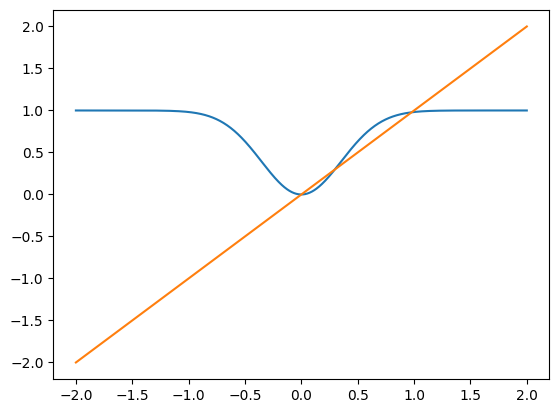

In [35]:
tt = np.linspace(-2, 2, 1000)
softplus = lambda x: np.log(1 + np.exp(x))
phi = lambda x: x * (1 - np.exp(-(x**2)))
plt.plot(tt, phi(tt * 2) / 2 / tt)
plt.plot(tt, tt)